# 01 — Hickey 2023 QC & Data Overview

**Purpose**: Verify data integrity, compute QC metrics, apply thresholds from config, characterise cell-type composition.
Two cohorts, two modalities — treated separately throughout.

---

## Dataset overview

Hickey et al. 2023 (*Science*) profiled the human gut cell atlas across multiple GI regions and donors using two distinct cohorts:

| Cohort | Donors | Modality | Samples (colon) | Cells |
|--------|--------|----------|-----------------|-------|
| RNA cohort | B001, B004, B005 | scRNA-seq only | 4 colon samples | 11,610 |
| ATAC/Multiome cohort | B006, B008–B012 | 10x Multiome (paired) | 22 colon samples | 102,453 |

Cells were pre-filtered using published Hickey annotation TSVs (whitelist approach) during the loading step (`scripts/data/load_hickey.py`). This notebook verifies the filtering results, computes additional QC metrics, applies config thresholds, and saves QC-filtered outputs for downstream analysis.

**Config thresholds** (`config/config.yaml`):
- RNA: min_genes=200, max_genes=5000, max_pct_mito=20%, n_top_genes=3000 HVGs
- ATAC: min_tss_enrichment=4, max_nucleosome_signal=2.0, min_unique_fragments=1000, max_blacklist_ratio=0.05

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sc.settings.verbosity = 2
sc.settings.figdir = "results/figures/hickey_qc/"
Path(sc.settings.figdir).mkdir(parents=True, exist_ok=True)

ROOT = Path("..").resolve()
PROC = ROOT / "data/processed/hickey2023"

print(f"Project root : {ROOT}")
print(f"Processed dir: {PROC}")
print(f"Figure dir   : {sc.settings.figdir}")

Project root : .
Processed dir: data/processed/hickey2023
Figure dir   : results/figures/hickey_qc


---
## Part 1 — RNA cohort (scRNA-seq)

Donors B001, B004, B005. Four colon samples, 11,610 cells × 45,068 genes.
Cells are pre-filtered by published Hickey annotation whitelists — we expect the vast majority to pass our QC thresholds.

In [2]:
# ── Load RNA merged object ──────────────────────────────────────────────────
rna = sc.read_h5ad(PROC / "rna_merged.h5ad")
print(f"RNA AnnData: {rna.shape[0]:,} cells × {rna.shape[1]:,} genes")
print()
print("obs columns:", rna.obs.columns.tolist())
print()
print("── obs.head(3) ──")
display(rna.obs.head(3))
print()
print("── Cell counts per sample ──")
print(rna.obs["sample_id"].value_counts())
print()
print("── Cell type distribution ──")
print(rna.obs["cell_type"].value_counts())
print()
print("── Compartment distribution ──")
print(rna.obs["compartment"].value_counts())

RNA AnnData: 11,610 cells × 45,068 genes

obs columns: ['sample_id', 'donor', 'cell_type', 'compartment', 'region']

── obs.head(3) ──


,sample_id,donor,cell_type,compartment,region
B001-A-301_AAACCCACAGCTATTG-1,B001-A-301,B001,TA1,colon_epithelial,Sigmoid
B001-A-301_AAACCCAGTGTTCCAA-1,B001-A-301,B001,Enterocytes,colon_epithelial,Sigmoid
B001-A-301_AAACGAAGTGGTATGG-1,B001-A-301,B001,Immature Enterocytes,colon_epithelial,Sigmoid



── Cell counts per sample ──
sample_id
B004-A-204    4504
B001-A-301    3523
B001-A-401    2037
B005-A-201    1546
Name: count, dtype: int64

── Cell type distribution ──
cell_type
TA2                                1786
TA1                                1778
Immature Enterocytes               1252
Immature Goblet                    1152
Enterocytes                         977
Myofibroblasts/SM 1                 722
CyclingTA 1                         691
Best4+ Enterocytes                  439
Myofibroblasts/SM DES High          439
Goblet                              360
Stem                                310
Mono_Macrophages                    205
Crypt Fibroblasts 3 RSPO3+          156
Crypt Fibroblasts 2                 136
Endothelial-CD36+ Microvascular     133
Crypt Fibroblasts 1 WNT2B+           96
B Cells                              90
Endothelial-Venules                  82
Glia                                 81
CD4                                  74
Plasma            

In [3]:
# ── Compute RNA QC metrics ──────────────────────────────────────────────────
# Identify mitochondrial genes by gene name prefix
rna.var["mt"] = rna.var_names.str.startswith("MT-")
n_mt = rna.var["mt"].sum()
print(f"Mitochondrial genes identified: {n_mt}")

sc.pp.calculate_qc_metrics(
    rna,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

print()
print("── Per-cell QC summary ──")
for col, label in [
    ("n_genes_by_counts", "Genes detected/cell"),
    ("total_counts",      "Total UMIs/cell"),
    ("pct_counts_mt",     "% mitochondrial counts"),
]:
    vals = rna.obs[col]
    print(f"  {label}:")
    print(f"    median={vals.median():.1f}  mean={vals.mean():.1f}  "
          f"max={vals.max():.1f}  min={vals.min():.1f}")

Mitochondrial genes identified: 13



── Per-cell QC summary ──
  Genes detected/cell:
    median=1419.0  mean=1539.0  max=5563.0  min=401.0
  Total UMIs/cell:
    median=2306.5  mean=3057.5  max=20001.0  min=440.0
  % mitochondrial counts:
    median=0.2  mean=0.5  max=5.0  min=0.0


In [4]:
# ── RNA QC violin plots ─────────────────────────────────────────────────────
# Three standard QC metrics; one panel per metric.
sc.pl.violin(
    rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False,
    save="_rna_qc.pdf",
)
plt.show()

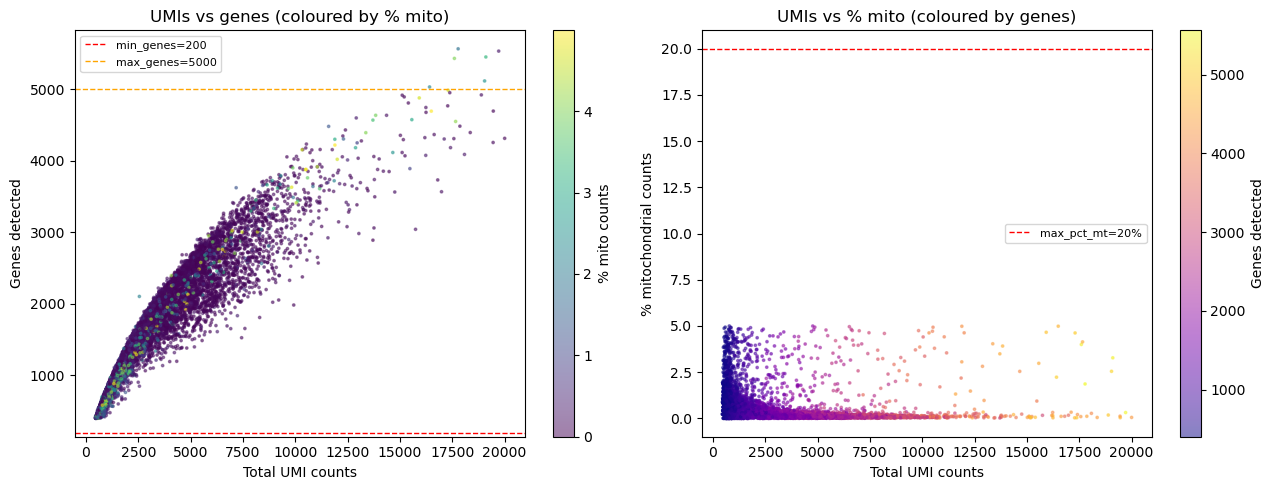

Saved: rna_qc_scatter.pdf


In [5]:
# ── RNA QC scatter plots ────────────────────────────────────────────────────
# Left panel : genes vs UMIs (coloured by % mito)
# Right panel: UMIs vs % mito (to identify high-mito / low-complexity cells)
# Threshold lines guide the eye.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: genes vs UMIs ──
ax = axes[0]
sc_plot = ax.scatter(
    rna.obs["total_counts"],
    rna.obs["n_genes_by_counts"],
    c=rna.obs["pct_counts_mt"],
    cmap="viridis",
    s=3,
    alpha=0.5,
    rasterized=True,
)
plt.colorbar(sc_plot, ax=ax, label="% mito counts")
ax.axhline(200,  color="red",    linestyle="--", lw=1, label="min_genes=200")
ax.axhline(5000, color="orange", linestyle="--", lw=1, label="max_genes=5000")
ax.set_xlabel("Total UMI counts")
ax.set_ylabel("Genes detected")
ax.set_title("UMIs vs genes (coloured by % mito)")
ax.legend(fontsize=8)

# ── Panel 2: UMIs vs % mito ──
ax = axes[1]
sc_plot2 = ax.scatter(
    rna.obs["total_counts"],
    rna.obs["pct_counts_mt"],
    c=rna.obs["n_genes_by_counts"],
    cmap="plasma",
    s=3,
    alpha=0.5,
    rasterized=True,
)
plt.colorbar(sc_plot2, ax=ax, label="Genes detected")
ax.axhline(20, color="red", linestyle="--", lw=1, label="max_pct_mt=20%")
ax.set_xlabel("Total UMI counts")
ax.set_ylabel("% mitochondrial counts")
ax.set_title("UMIs vs % mito (coloured by genes)")
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(f"{sc.settings.figdir}/rna_qc_scatter.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rna_qc_scatter.pdf")

In [6]:
# ── Apply RNA QC thresholds (from config/config.yaml) ──────────────────────
# Cells are already pre-filtered by the Hickey published annotations,
# so we expect near-total retention. The thresholds are applied for
# reproducibility and to flag any outliers introduced during merging.

MIN_GENES  = 200
MAX_GENES  = 5000
MAX_PCT_MT = 20.0

pre = rna.n_obs
rna_qc = rna[
    (rna.obs["n_genes_by_counts"] >= MIN_GENES) &
    (rna.obs["n_genes_by_counts"] <= MAX_GENES) &
    (rna.obs["pct_counts_mt"]     <= MAX_PCT_MT)
].copy()

print(f"RNA QC filter results")
print(f"  Before : {pre:,} cells")
print(f"  After  : {rna_qc.n_obs:,} cells retained ({100 * rna_qc.n_obs / pre:.2f}%)")
print(f"  Removed: {pre - rna_qc.n_obs:,} cells")
print()
print("── Breakdown by filter criterion ──")
for label, mask in [
    (f"n_genes < {MIN_GENES}  (too few genes)",  rna.obs["n_genes_by_counts"] < MIN_GENES),
    (f"n_genes > {MAX_GENES} (too many genes)",  rna.obs["n_genes_by_counts"] > MAX_GENES),
    (f"pct_mt  > {MAX_PCT_MT}%  (high mito)",    rna.obs["pct_counts_mt"] > MAX_PCT_MT),
]:
    print(f"  {label}: {mask.sum():,} cells")

RNA QC filter results
  Before : 11,610 cells
  After  : 11,604 cells retained (99.95%)
  Removed: 6 cells

── Breakdown by filter criterion ──
  n_genes < 200  (too few genes): 0 cells
  n_genes > 5000 (too many genes): 6 cells
  pct_mt  > 20.0%  (high mito): 0 cells


── Cell counts by cell_type × compartment ──


compartment,colon_epithelial,immune,stromal
cell_type,,,
Adipocytes,0,0,11
B Cells,0,90,0
Best4+ Enterocytes,439,0,0
CD4,0,74,0
CD8,0,59,0
Crypt Fibroblasts 1 WNT2B+,0,0,96
Crypt Fibroblasts 2,0,0,136
Crypt Fibroblasts 3 RSPO3+,0,0,156
CyclingImmune,0,18,0


/var/folders/0m/d72k05nn1vg0nkl3jwb_3bgm0000gq/T/ipykernel_66784/1632131090.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20", n_types)


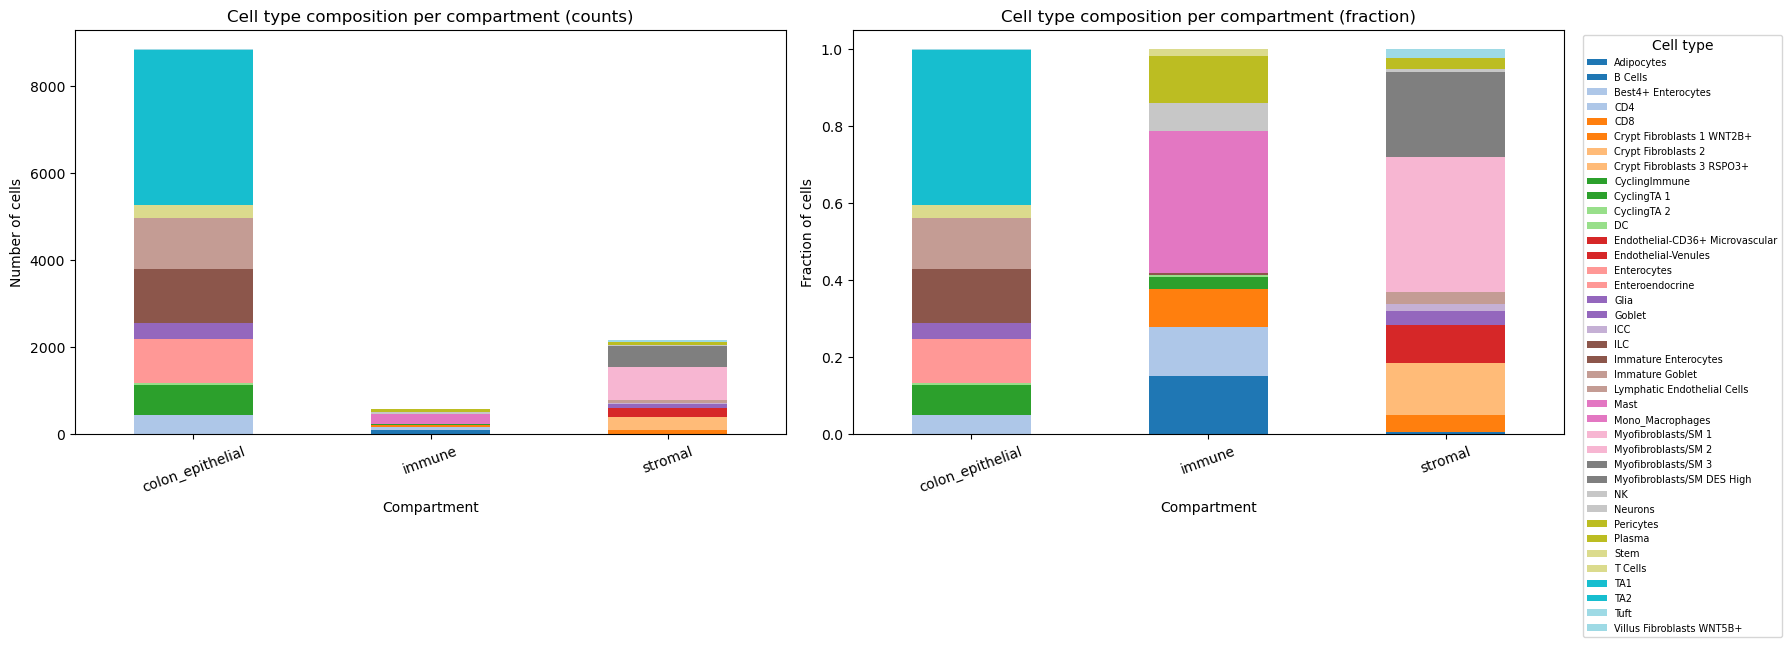

Saved: rna_celltype_composition.pdf


In [7]:
# ── RNA cell-type composition ───────────────────────────────────────────────
# Cross-tabulate compartment × cell_type to see how cell types distribute
# across the three compartments (epithelial, stromal, immune).

ct_table = pd.crosstab(rna_qc.obs["cell_type"], rna_qc.obs["compartment"])
print("── Cell counts by cell_type × compartment ──")
display(ct_table)

# Stacked bar chart: compartment on x-axis, stacked by cell type
comp_ct = pd.crosstab(rna_qc.obs["compartment"], rna_qc.obs["cell_type"])

# Use a qualitative palette (tab20 for many cell types)
n_types = comp_ct.shape[1]
palette = plt.cm.get_cmap("tab20", n_types)
colors  = [palette(i) for i in range(n_types)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: absolute counts ──
comp_ct.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Cell type composition per compartment (counts)")
axes[0].set_xlabel("Compartment")
axes[0].set_ylabel("Number of cells")
axes[0].tick_params(axis="x", rotation=20)

# ── Right: proportions ──
comp_ct_norm = comp_ct.div(comp_ct.sum(axis=1), axis=0)
comp_ct_norm.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=axes[1],
)
axes[1].set_title("Cell type composition per compartment (fraction)")
axes[1].set_xlabel("Compartment")
axes[1].set_ylabel("Fraction of cells")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(
    title="Cell type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
)

plt.tight_layout()
fig.savefig(f"{sc.settings.figdir}/rna_celltype_composition.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rna_celltype_composition.pdf")

normalizing counts per cell


    finished (0:00:00)


extracting highly variable genes


<env>/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


HVGs selected: 3,000 / 45,068 genes (6.7%)


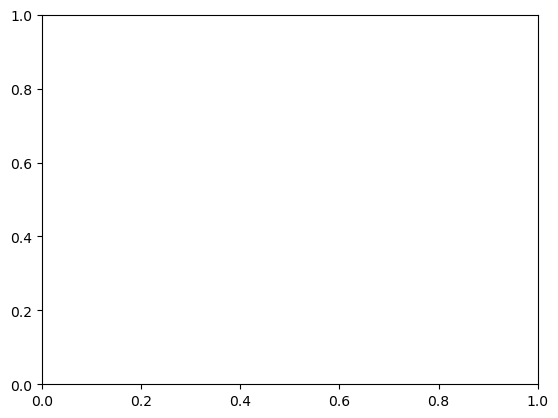

In [8]:
# ── HVG selection ───────────────────────────────────────────────────────────
# Standard scanpy preprocessing:
#   1. Normalize to 10,000 counts/cell (library-size correction)
#   2. Log1p transform
#   3. Select 3,000 highly variable genes (seurat_v3 flavour, batch-aware)
#
# batch_key="sample_id" ensures HVGs are selected consistently across the
# four colon samples (takes the union of per-batch top-N genes weighted by
# a dispersion score). This guards against sample-specific batch effects
# dominating the gene selection.

sc.pp.normalize_total(rna_qc, target_sum=1e4)
sc.pp.log1p(rna_qc)
sc.pp.highly_variable_genes(
    rna_qc,
    n_top_genes=3000,
    flavor="seurat_v3",
    batch_key="sample_id",
)

n_hvg = rna_qc.var["highly_variable"].sum()
print(f"HVGs selected: {n_hvg:,} / {rna_qc.n_vars:,} genes ({100 * n_hvg / rna_qc.n_vars:.1f}%)")

# Quick look at the highly variable gene plot
sc.pl.highly_variable_genes(rna_qc, show=False, save="_rna_hvg.pdf")
plt.show()

In [9]:
# ── RNA PCA + neighbourhood graph + UMAP + Leiden clustering ───────────────
# Scaling clips extreme values (max_value=10) to reduce the influence of
# outlier genes. PCA is restricted to HVGs. Leiden clustering at resolution
# 0.5 provides a coarse-grained community structure for QC purposes.

sc.pp.scale(rna_qc, max_value=10)
sc.tl.pca(rna_qc, n_comps=30, use_highly_variable=True)
sc.pp.neighbors(rna_qc, n_pcs=30)
sc.tl.umap(rna_qc)
sc.tl.leiden(rna_qc, resolution=0.5, key_added="leiden")

print(f"Leiden clusters: {rna_qc.obs['leiden'].nunique()}")
print(rna_qc.obs["leiden"].value_counts().sort_index())

<env>/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA


    with n_comps=30


<env>/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:01)


...

    finished (0:00:05)


running Leiden clustering


/var/folders/0m/d72k05nn1vg0nkl3jwb_3bgm0000gq/T/ipykernel_66784/3618613819.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna_qc, resolution=0.5, key_added="leiden")


    finished (0:00:04)


Leiden clusters: 27
leiden
0     1641
1     1402
2     1088
3      945
4      802
5      735
6      719
7      553
8      440
9      434
10     351
11     290
12     286
13     254
14     244
15     228
16     212
17     204
18     170
19     137
20     119
21      93
22      81
23      67
24      54
25      44
26      11
Name: count, dtype: int64


In [10]:
# ── RNA UMAP visualisation ──────────────────────────────────────────────────
# Four panels show the UMAP embedding coloured by:
#   1. Annotated cell type (from Hickey labels)
#   2. Tissue compartment
#   3. Sample of origin (batch check)
#   4. Leiden clusters at resolution 0.5 (unsupervised structure)
#
# Good concordance between cell_type and leiden validates the embedding.
# Sample mixing on UMAP indicates no strong batch effect.

sc.pl.umap(
    rna_qc,
    color=["cell_type", "compartment", "sample_id", "leiden"],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=6,
    frameon=False,
    show=False,
    save="_rna_umap.pdf",
)
plt.show()
print("Saved: umap_rna_umap.pdf")

Saved: umap_rna_umap.pdf


---
## Part 2 — ATAC cohort (10x Multiome)

Donors B006, B008–B012. Six donors, 102,453 cells × 1,126,541 peaks.
These cells come from the Multiome ATAC modality of the Hickey dataset and are annotated with cell types transferred from the Multiome RNA. The merged object holds the **union** of peaks across all three compartments — this is important for interpretation (see the peak universe note below).

Because we work with a pre-computed peak matrix (not raw fragments), we **cannot** compute TSS enrichment scores or nucleosome signal directly. Instead we use accessible peaks per cell as the primary QC metric, and flag cells with very few open peaks as low-quality.

In [11]:
# ── Load ATAC merged object ─────────────────────────────────────────────────
atac = sc.read_h5ad(PROC / "atac_merged.h5ad")
print(f"ATAC AnnData: {atac.shape[0]:,} cells × {atac.shape[1]:,} peaks")
print()
print("obs columns:", atac.obs.columns.tolist())
print()
print("── obs.head(3) ──")
display(atac.obs.head(3))
print()
print("── Cells per compartment ──")
print(atac.obs["compartment"].value_counts())
print()
print("── Cells per donor ──")
print(atac.obs["donor"].value_counts())

ATAC AnnData: 102,453 cells × 1,126,541 peaks

obs columns: ['barcode', 'sample_id', 'donor', 'compartment', 'cell_type', 'region']

── obs.head(3) ──


,barcode,sample_id,donor,compartment,cell_type,region
B010-A-201#TAGCAGGCAATAGCCC-1_0,B010-A-201#TAGCAGGCAATAGCCC-1,B010-A-201,B010,colon_epithelial,TA1,Ascending
B010-A-201#GTCCAAGTCCATTACT-1_0,B010-A-201#GTCCAAGTCCATTACT-1,B010-A-201,B010,colon_epithelial,TA1,Ascending
B010-A-201#GGTAAACCATAAGCAA-1_0,B010-A-201#GGTAAACCATAAGCAA-1,B010-A-201,B010,colon_epithelial,Immature Enterocytes,Ascending



── Cells per compartment ──
compartment
colon_epithelial    44580
stromal             32732
immune              25141
Name: count, dtype: int64

── Cells per donor ──
donor
B010    30388
B012    24669
B008    22563
B011    14553
B006     5256
B009     5024
Name: count, dtype: int64


In [12]:
# ── Compute ATAC QC metrics ─────────────────────────────────────────────────
# From the peak matrix we can compute:
#   n_accessible_peaks : number of peaks with any signal (binary accessibility)
#   total_accessibility: sum of all peak scores per cell (analogous to total counts)
#
# Both handle sparse and dense X via np.asarray().ravel().

print("Computing per-cell ATAC QC metrics (may take a moment for 100k cells)...")
atac.obs["n_accessible_peaks"] = np.asarray((atac.X > 0).sum(axis=1)).ravel()
atac.obs["total_accessibility"] = np.asarray(atac.X.sum(axis=1)).ravel()

print("Done.")
print()
print("── Per-compartment accessible peak summary ──")
for comp in ["colon_epithelial", "immune", "stromal"]:
    sub = atac.obs[atac.obs["compartment"] == comp]
    pk  = sub["n_accessible_peaks"]
    print(
        f"  {comp:<22}: n={len(sub):>6,}  "
        f"median={pk.median():.0f}  mean={pk.mean():.0f}  "
        f"min={pk.min():.0f}  max={pk.max():.0f}"
    )
print()
print("── Overall summary ──")
for col, label in [
    ("n_accessible_peaks", "Accessible peaks/cell"),
    ("total_accessibility", "Total accessibility score/cell"),
]:
    vals = atac.obs[col]
    print(f"  {label}: median={vals.median():.0f}  mean={vals.mean():.0f}  max={vals.max():.0f}")

Computing per-cell ATAC QC metrics (may take a moment for 100k cells)...


Done.

── Per-compartment accessible peak summary ──
  colon_epithelial      : n=44,580  median=6802  mean=8098  min=349  max=52894
  immune                : n=25,141  median=2833  mean=3382  min=341  max=31177
  stromal               : n=32,732  median=4495  mean=5284  min=341  max=44894

── Overall summary ──
  Accessible peaks/cell: median=4705  mean=6042  max=52894
  Total accessibility score/cell: median=8084  mean=10592  max=105754


/var/folders/0m/d72k05nn1vg0nkl3jwb_3bgm0000gq/T/ipykernel_66784/3673346242.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/0m/d72k05nn1vg0nkl3jwb_3bgm0000gq/T/ipykernel_66784/3673346242.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


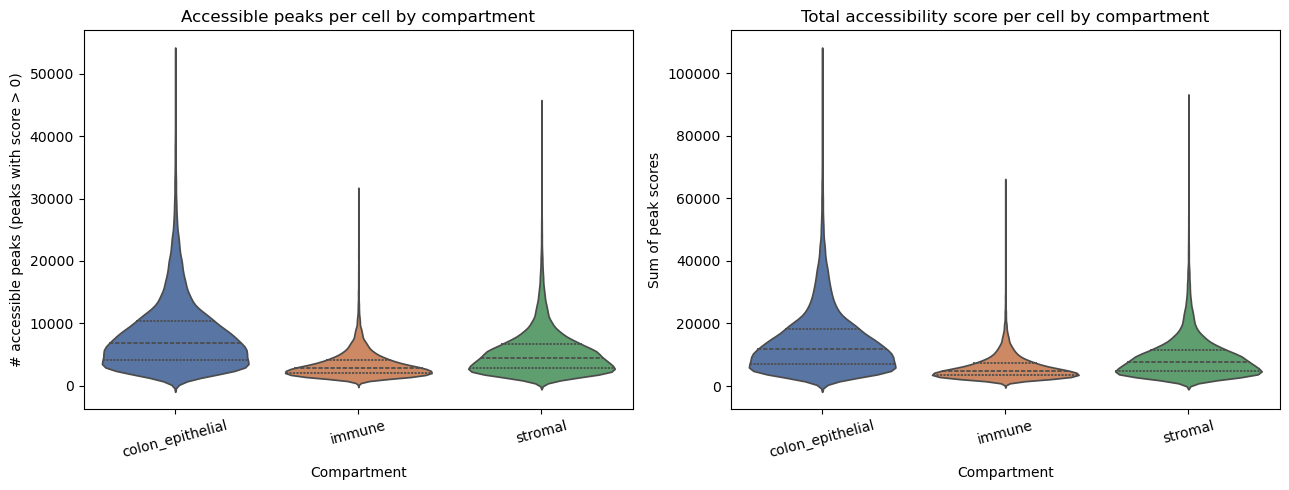

Saved: atac_qc_violins.pdf


In [13]:
# ── ATAC QC violin plots by compartment ────────────────────────────────────
# The number of accessible peaks per cell varies considerably between
# compartments (epithelial cells tend to have more open chromatin than
# immune cells in this dataset). Visualising per compartment separates
# biological differences from technical low-quality cells.

COMP_PALETTE = {
    "colon_epithelial": "#4C72B0",
    "immune":           "#DD8452",
    "stromal":          "#55A868",
}
comp_order = ["colon_epithelial", "immune", "stromal"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: accessible peaks ──
sns.violinplot(
    data=atac.obs,
    x="compartment",
    y="n_accessible_peaks",
    order=comp_order,
    palette=COMP_PALETTE,
    inner="quartile",
    ax=axes[0],
)
axes[0].set_title("Accessible peaks per cell by compartment")
axes[0].set_xlabel("Compartment")
axes[0].set_ylabel("# accessible peaks (peaks with score > 0)")
axes[0].tick_params(axis="x", rotation=15)

# ── Panel 2: total accessibility score ──
sns.violinplot(
    data=atac.obs,
    x="compartment",
    y="total_accessibility",
    order=comp_order,
    palette=COMP_PALETTE,
    inner="quartile",
    ax=axes[1],
)
axes[1].set_title("Total accessibility score per cell by compartment")
axes[1].set_xlabel("Compartment")
axes[1].set_ylabel("Sum of peak scores")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(f"{sc.settings.figdir}/atac_qc_violins.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: atac_qc_violins.pdf")

── ATAC cell counts by compartment × cell_type (top 30 types shown) ──


cell_type,B Cells,Best4+ Enterocytes,CD4,CD8,Crypt Fibroblasts 1 WNT2B+,Crypt Fibroblasts 2,Crypt Fibroblasts 3 RSPO3+,CyclingTA 1,CyclingTA 2,Endothelial-CD36+ Microvascular,...,Myofibroblasts/SM 2,Myofibroblasts/SM 3,Myofibroblasts/SM DES High,NK,Pericytes,Plasma,Stem,TA1,TA2,Villus Fibroblasts WNT5B+
compartment,,,,,,,,,,,,,,,,,,,,,
colon_epithelial,0,2431,0,0,0,0,0,6797,719,0,...,0,0,0,0,0,0,2237,9737,5784,0
immune,3267,0,3570,5585,0,0,0,0,0,0,...,0,0,0,1269,0,5160,0,0,0,0
stromal,0,0,0,0,4633,1616,3736,0,0,1964,...,1052,1707,2872,0,1026,0,0,0,0,1474



── Top 20 cell types overall ──
cell_type
TA1                                9737
Myofibroblasts/SM 1                8724
CyclingTA 1                        6797
TA2                                5784
CD8                                5585
Immature Enterocytes               5425
Plasma                             5160
Immature Goblet                    5043
Mono_Macrophages                   4687
Crypt Fibroblasts 1 WNT2B+         4633
Enterocytes                        4459
Crypt Fibroblasts 3 RSPO3+         3736
CD4                                3570
B Cells                            3267
Myofibroblasts/SM DES High         2872
Best4+ Enterocytes                 2431
Stem                               2237
Endothelial-CD36+ Microvascular    1964
Myofibroblasts/SM 3                1707
Crypt Fibroblasts 2                1616
Name: count, dtype: int64


/var/folders/0m/d72k05nn1vg0nkl3jwb_3bgm0000gq/T/ipykernel_66784/1056246335.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette_atac = plt.cm.get_cmap("tab20", min(n_types_atac, 20))


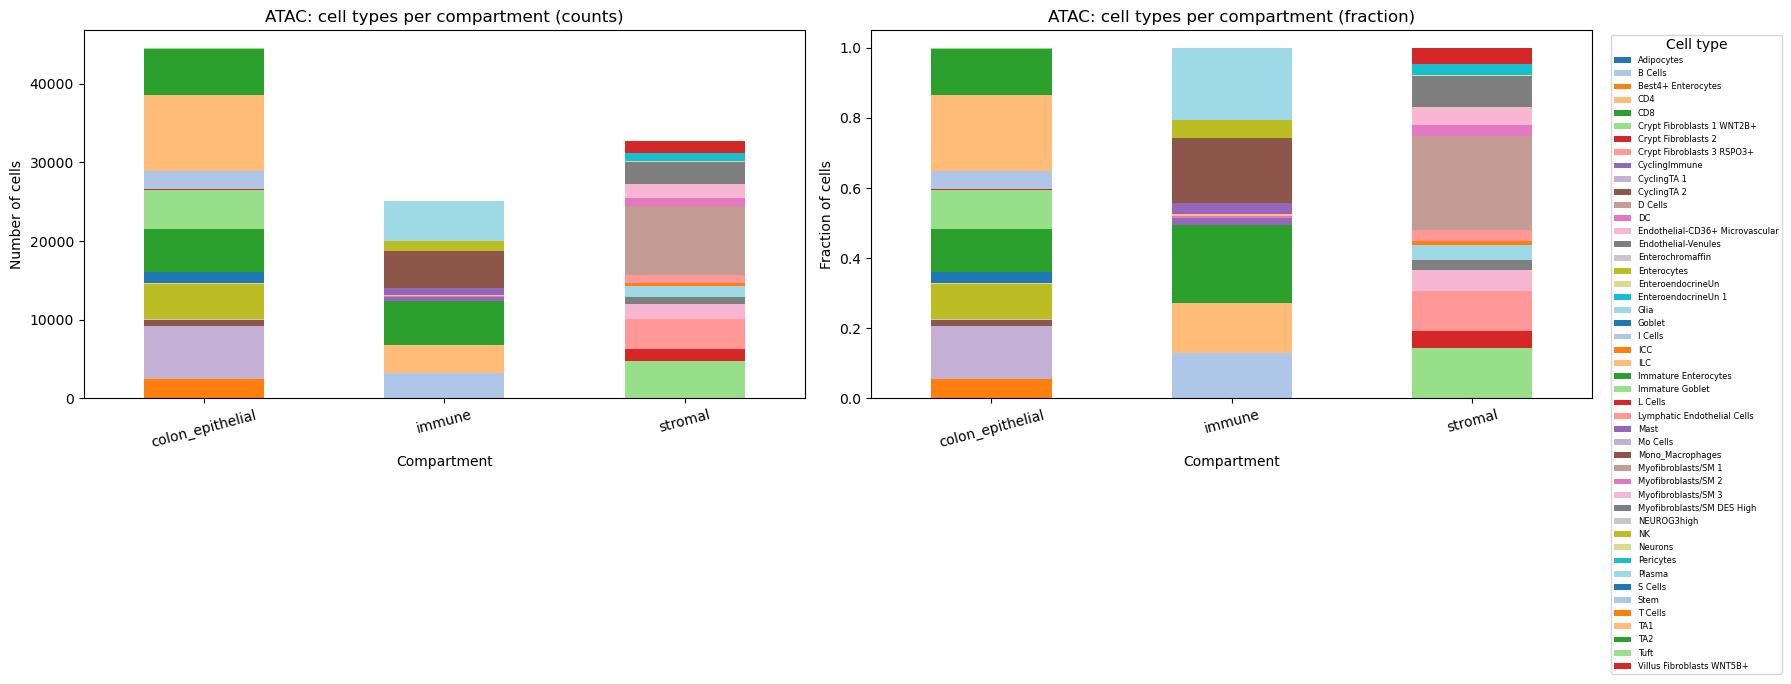

Saved: atac_celltype_composition.pdf


In [14]:
# ── ATAC cell-type composition ──────────────────────────────────────────────
# Cell types in the ATAC object are transferred from the Multiome RNA
# annotation. Some compartments may have coarser annotations than others.

comp_ct_atac = pd.crosstab(atac.obs["compartment"], atac.obs["cell_type"])
print("── ATAC cell counts by compartment × cell_type (top 30 types shown) ──")
# Show counts sorted by total
top_types = atac.obs["cell_type"].value_counts().head(30).index
display(comp_ct_atac[comp_ct_atac.columns.intersection(top_types)])

# Overall cell type distribution
print()
print("── Top 20 cell types overall ──")
print(atac.obs["cell_type"].value_counts().head(20))

# Stacked bar chart — proportion per compartment
n_types_atac = comp_ct_atac.shape[1]
palette_atac = plt.cm.get_cmap("tab20", min(n_types_atac, 20))
colors_atac  = [palette_atac(i % 20) for i in range(n_types_atac)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

comp_ct_atac.plot(
    kind="bar", stacked=True, color=colors_atac, ax=axes[0], legend=False
)
axes[0].set_title("ATAC: cell types per compartment (counts)")
axes[0].set_xlabel("Compartment")
axes[0].set_ylabel("Number of cells")
axes[0].tick_params(axis="x", rotation=15)

comp_ct_atac_norm = comp_ct_atac.div(comp_ct_atac.sum(axis=1), axis=0)
comp_ct_atac_norm.plot(
    kind="bar", stacked=True, color=colors_atac, ax=axes[1]
)
axes[1].set_title("ATAC: cell types per compartment (fraction)")
axes[1].set_xlabel("Compartment")
axes[1].set_ylabel("Fraction of cells")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(
    title="Cell type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=6,
)

plt.tight_layout()
fig.savefig(f"{sc.settings.figdir}/atac_celltype_composition.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: atac_celltype_composition.pdf")

### Peak universe — important note

The merged ATAC object (`atac_merged.h5ad`) contains **1,126,541 peaks**, which is the **union** of three separate compartment-level peak call sets:

| Compartment | Peaks in its own call set |
|-------------|---------------------------|
| colon_epithelial | 509,414 |
| immune | 242,814 |
| stromal | 376,977 |
| **Union (merged object)** | **~1,126,541** |

The union was created with an outer join during loading. This means:

- An **epithelial cell** will have zero signal at the ~617k peaks that were only called in immune/stromal samples. Those zeros are structural, not biological.
- Using the full 1.1M-peak matrix for a compartment-specific analysis (e.g., peak–gene linking in epithelial cells) is wasteful and inflates sparsity. The effective peak universe for epithelial cells is ~509k.

**Strategy for downstream analysis**: always **subset by compartment first**, then **remove absent peaks** (`sc.pp.filter_genes(sub, min_cells=1)`). The next cell does exactly this and saves per-compartment h5ad files.

In [15]:
# ── Subset ATAC per compartment and remove absent peaks ─────────────────────
# For each compartment we:
#   1. Select cells belonging to that compartment
#   2. Drop peaks that are all-zero within this cell set (peaks from other compartments)
#   3. Save to a separate h5ad for use in downstream peak-gene linkage workflows
#
# filter_genes(min_cells=1) removes any feature (peak) that has zero counts
# in all cells of the subset — exactly what we want.

print("Subsetting ATAC by compartment and removing absent peaks...\n")
for comp in ["colon_epithelial", "immune", "stromal"]:
    sub = atac[atac.obs["compartment"] == comp].copy()
    print(f"{comp}:")
    print(f"  Cells before   : {sub.n_obs:>7,}")
    print(f"  Peaks before   : {sub.n_vars:>7,}")
    sc.pp.filter_genes(sub, min_cells=1)
    print(f"  Peaks after    : {sub.n_vars:>7,}  (removed {atac.n_vars - sub.n_vars:,} absent peaks)")
    sparsity = 1 - (sub.X > 0).mean()
    print(f"  Sparsity       : {float(sparsity):.3f}")
    out = PROC / f"atac_{comp}.h5ad"
    sub.write_h5ad(out)
    print(f"  Saved → {out}")
    print()

Subsetting ATAC by compartment and removing absent peaks...



colon_epithelial:
  Cells before   :  44,580
  Peaks before   : 1,126,541


filtered out 617127 genes that are detected in less than 1 cells


  Peaks after    : 509,414  (removed 617,127 absent peaks)


  Sparsity       : 0.984


...

stromal:
  Cells before   :  32,732
  Peaks before   : 1,126,541


filtered out 749564 genes that are detected in less than 1 cells


  Peaks after    : 376,977  (removed 749,564 absent peaks)


  Sparsity       : 0.986


  Saved → data/processed/hickey2023/atac_stromal.h5ad



In [16]:
# ── Save QC-filtered RNA ────────────────────────────────────────────────────
# rna_qc contains normalized, log-transformed, scaled counts and a UMAP
# embedding. This is the canonical QC-passed RNA object for downstream use.

out_rna = PROC / "rna_qc.h5ad"
rna_qc.write_h5ad(out_rna)
print(f"Saved QC RNA: {rna_qc.n_obs:,} cells × {rna_qc.n_vars:,} genes → {out_rna}")

Saved QC RNA: 11,604 cells × 45,068 genes → data/processed/hickey2023/rna_qc.h5ad


---
## Summary

### QC results at a glance

| Metric | RNA cohort | ATAC cohort |
|--------|------------|-------------|
| Input cells | 11,610 | 102,453 |
| Donors | B001, B004, B005 | B006, B008–B012 |
| Samples (colon) | 4 | 22 |
| QC thresholds applied | min_genes=200, max_genes=5000, max_pct_mt=20% | accessible peaks per cell (compartment-stratified) |
| TSS enrichment | N/A | Not computable from peak matrix; fragment files needed |

### Outputs written

| File | Contents |
|------|----------|
| `data/processed/hickey2023/rna_qc.h5ad` | QC-filtered RNA: normalized, log1p, scaled; UMAP + Leiden |
| `data/processed/hickey2023/atac_colon_epithelial.h5ad` | ~44.6k epithelial cells, ~509k peaks |
| `data/processed/hickey2023/atac_immune.h5ad` | ~25.1k immune cells, ~243k peaks |
| `data/processed/hickey2023/atac_stromal.h5ad` | ~32.7k stromal cells, ~377k peaks |

### Key observations

1. **RNA**: Cells are tightly pre-filtered by Hickey annotations — near-total retention through QC thresholds is expected. The UMAP shows good concordance between annotated cell types and unsupervised Leiden clusters. Samples mix well, indicating no dominant batch effect.

2. **ATAC**: Accessible peak counts differ strongly by compartment (epithelial > stromal > immune), reflecting biological differences in chromatin accessibility. This compartment-stratified pattern is expected and not a QC artefact.

3. **Peak universe**: The merged 1.1M-peak ATAC object uses a union of compartment-specific peak sets. Per-compartment subsets with absent peaks removed are the correct input for all linkage methods.

4. **TSS enrichment**: Cannot be computed from the pre-aggregated peak matrix. Fragment-level QC was performed by Hickey et al. before publication; cell barcodes passing their filters are included. If fragment files are downloaded, TSS enrichment can be recalculated using SnapATAC2.

### Next steps

- `02_hickey_pseudobulk.ipynb`: aggregate RNA and ATAC per cell type per donor for pseudo-bulk analysis
- `03_linkage_*.ipynb`: run peak–gene linkage methods on pseudo-bulk matrices